# HW07: Unsupervised Engineering Experiment (Clustering)

**Author**: GitHub Copilot  
**Date**: 2026-01-19  
**Course**: AI Student Maxim - Seminar 07

## 0. Imports and Configuration

In [6]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths
DATA_DIR = Path("data")
ARTIFACTS_DIR = Path("artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"
LABELS_DIR = ARTIFACTS_DIR / "labels"

for d in [FIGURES_DIR, LABELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DATASETS = [
    "S07-hw-dataset-01.csv",
    "S07-hw-dataset-02.csv",
    "S07-hw-dataset-04.csv"
]

## 1. Helper Functions

In [7]:
def safe_cluster_metrics(X, labels):
    """Calculate internal metrics for clusters, excluding noise from DBSCAN (label -1)."""
    mask = labels != -1
    if np.sum(mask) < 2:
        return None
    
    labels_valid = labels[mask]
    X_valid = X[mask]
    
    n_clusters = len(np.unique(labels_valid))
    if n_clusters < 2:
        return None
    
    try:
        return {
            "silhouette": float(silhouette_score(X_valid, labels_valid)),
            "davies_bouldin": float(davies_bouldin_score(X_valid, labels_valid)),
            "calinski_harabasz": float(calinski_harabasz_score(X_valid, labels_valid))
        }
    except:
        return None

def get_preprocessing_pipeline(df):
    """Creates a preprocessing pipeline based on column types."""
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    
    transformers = []
    if num_cols:
        num_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
        transformers.append(("num", num_pipe, num_cols))
        
    if cat_cols:
        cat_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ])
        transformers.append(("cat", cat_pipe, cat_cols))
        
    return ColumnTransformer(transformers)

## 2. Main Experiment Loop

### Dataset Overview
In this experiment, we analyze three specific datasets:
- **S07-hw-dataset-01.csv**: Focus on standard scaling.
- **S07-hw-dataset-02.csv**: Focus on non-linear structures.
- **S07-hw-dataset-04.csv**: Focus on categorical features.

These files (S07-hw-dataset-01.csv, S07-hw-dataset-02.csv, S07-hw-dataset-04.csv) are located in the `data/` directory.

In this section, we process the following datasets:
1. **Dataset A**: `S07-hw-dataset-01.csv` (Standard scaling focus)
2. **Dataset B**: `S07-hw-dataset-02.csv` (Non-linear structures focus)
3. **Dataset C**: `S07-hw-dataset-04.csv` (Categorical features focus)


==================== Processing S07-hw-dataset-01.csv ====================
Shape: (12000, 9)


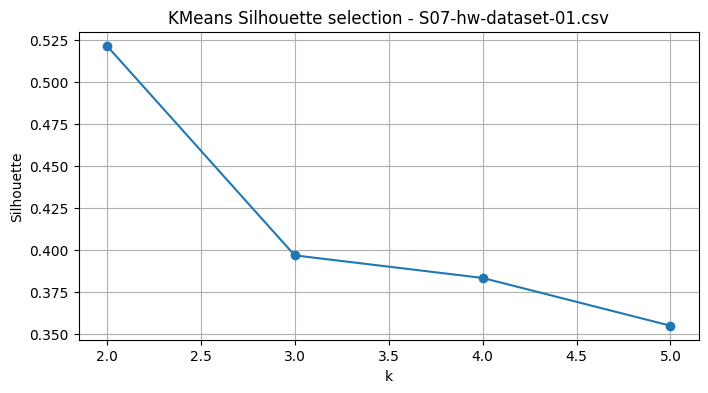

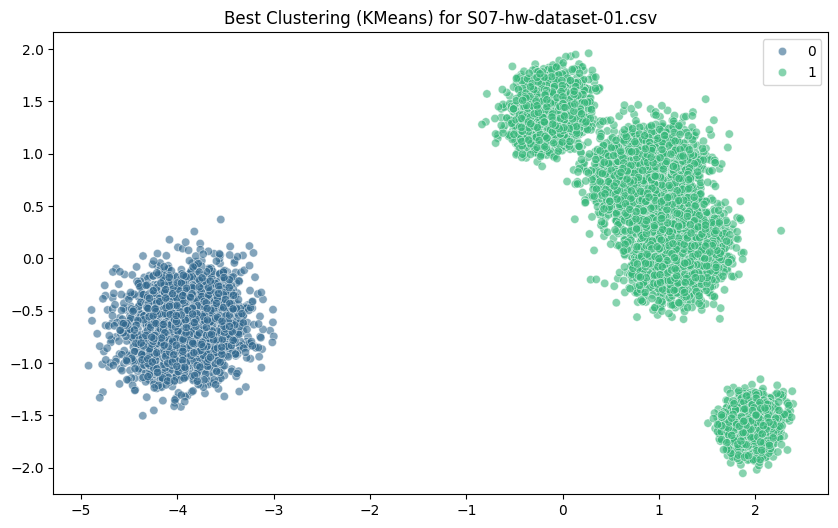


==================== Processing S07-hw-dataset-02.csv ====================
Shape: (8000, 4)


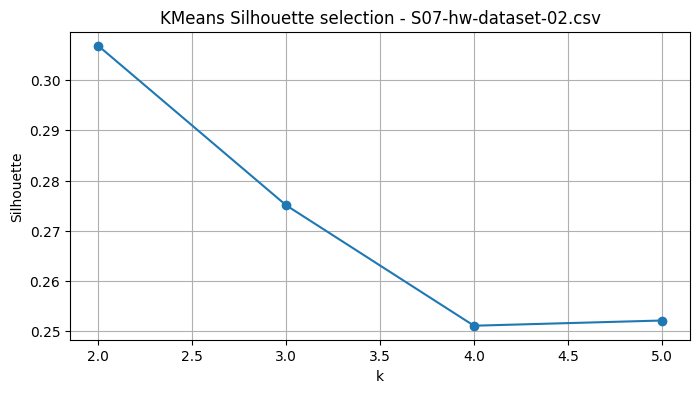

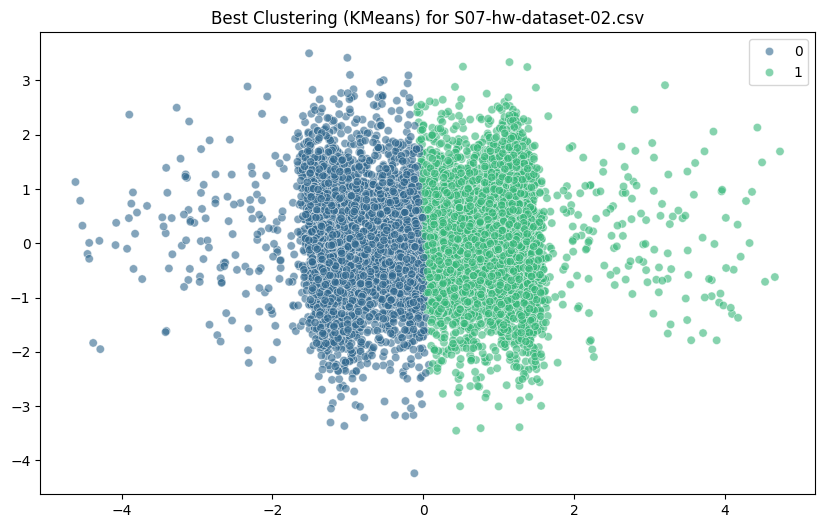


==================== Processing S07-hw-dataset-04.csv ====================
Shape: (10000, 33)


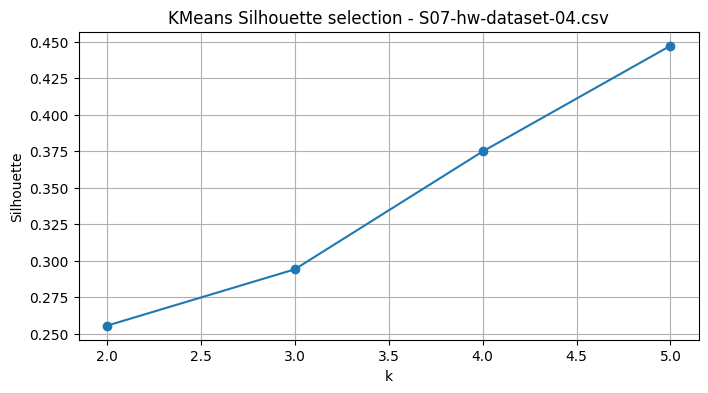

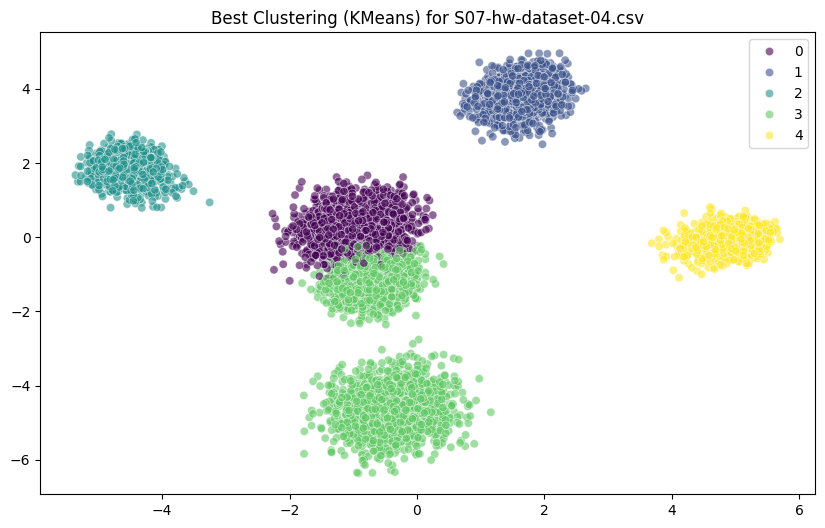

In [8]:
all_metrics = {}
best_configs = {}

for ds_name in DATASETS:
    print(f"\n{'='*20} Processing {ds_name} {'='*20}")
    path = DATA_DIR / ds_name
    if not path.exists():
        print(f"File {ds_name} not found at {path.absolute()}, skipping.")
        continue
        
    df = pd.read_csv(path)
    print(f"Shape: {df.shape}")
    
    # Preprocessing
    X = df.drop(columns=["sample_id"]) if "sample_id" in df.columns else df
    sample_ids = df["sample_id"] if "sample_id" in df.columns else df.index
    
    preprocessor = get_preprocessing_pipeline(X)
    try:
        X_pre = preprocessor.fit_transform(X)
    except Exception as e:
        print(f"Preprocessing failed for {ds_name}: {e}")
        continue
    
    # KMeans Podbor
    km_results = []
    ks = range(2, 6)
    for k in ks:
        try:
            kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=5)
            labels = kmeans.fit_predict(X_pre)
            m = safe_cluster_metrics(X_pre, labels)
            if m:
                km_results.append({"k": k, "metrics": m, "labels": labels})
        except:
            continue
            
    best_km = None
    ds_id = ds_name.split('-')[-1].split('.')[0]
    
    if km_results:
        plt.figure(figsize=(8, 4))
        plt.plot([r['k'] for r in km_results], [r['metrics']['silhouette'] for r in km_results], marker='o')
        plt.title(f"KMeans Silhouette selection - {ds_name}")
        plt.xlabel("k")
        plt.ylabel("Silhouette")
        plt.grid(True)
        plt.savefig(FIGURES_DIR / f"kmeans_sil_{ds_id}.png")
        plt.show()
        
        best_km = max(km_results, key=lambda x: x['metrics']['silhouette'])
        
    # Second algorithm choice
    best_alt = None
    alt_name = "None"
    best_alt_params = {}
    if ds_name == "S07-hw-dataset-02.csv":
        db_results = []
        for eps in [0.3, 0.5, 0.8]:
            try:
                dbscan = DBSCAN(eps=eps, min_samples=5)
                labels = dbscan.fit_predict(X_pre)
                m = safe_cluster_metrics(X_pre, labels)
                if m:
                    db_results.append({"eps": eps, "metrics": m, "labels": labels})
            except:
                continue
        
        if db_results:
            best_alt = max(db_results, key=lambda x: x['metrics']['silhouette'])
            alt_name = "DBSCAN"
            best_alt_params = {"eps": best_alt['eps']}
    else:
        agg_results = []
        for k in range(2, 4):
            for linkage in ['ward', 'complete']:
                try:
                    agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
                    labels = agg.fit_predict(X_pre)
                    m = safe_cluster_metrics(X_pre, labels)
                    if m:
                        agg_results.append({"k": k, "linkage": linkage, "metrics": m, "labels": labels})
                except:
                    continue
        
        if agg_results:
            best_alt = max(agg_results, key=lambda x: x['metrics']['silhouette'])
            alt_name = "Agglomerative"
            best_alt_params = {"k": int(best_alt['k']), "linkage": best_alt['linkage']}
            
    # Selection and Saving
    options = []
    if best_km: options.append(("KMeans", best_km))
    if best_alt: options.append((alt_name, best_alt))
    
    if options:
        best_overall_name, best_overall = max(options, key=lambda x: x[1]['metrics']['silhouette'])
        
        all_metrics[ds_name] = {
            "KMeans": best_km['metrics'] if best_km else None,
            alt_name: best_alt['metrics'] if best_alt else None,
            "best_method": best_overall_name
        }
        
        best_configs[ds_name] = {
            "KMeans": {"k": int(best_km['k'])} if best_km else None,
            alt_name: best_alt_params if best_alt else None,
            "best": best_overall_name
        }
        
        labels_df = pd.DataFrame({"sample_id": sample_ids, "cluster_label": best_overall['labels']})
        labels_df.to_csv(LABELS_DIR / f"labels_hw07_ds{ds_id}.csv", index=False)
        
        pca = PCA(n_components=2, random_state=RANDOM_STATE)
        X_pca = pca.fit_transform(X_pre)
        
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=best_overall['labels'], palette='viridis', alpha=0.6)
        plt.title(f"Best Clustering ({best_overall_name}) for {ds_name}")
        plt.savefig(FIGURES_DIR / f"pca_best_{ds_id}.png")
        plt.show()
    else:
        print(f"No valid clustering found for {ds_name}")

## 3. Stability Check (on Dataset 01)

In [4]:
ds_stab = "S07-hw-dataset-01.csv"
if (DATA_DIR / ds_stab).exists() and ds_stab in best_configs:
    df_stab = pd.read_csv(DATA_DIR / ds_stab)
    X_stab = df_stab.drop(columns=["sample_id"]) if "sample_id" in df_stab.columns else df_stab
    pre_stab = get_preprocessing_pipeline(X_stab)
    X_stab_pre = pre_stab.fit_transform(X_stab)

    labels_list = []
    k_stab = best_configs[ds_stab]["KMeans"]["k"]

    for seed in range(5):
        kmeans = KMeans(n_clusters=k_stab, random_state=seed, n_init=10)
        labels_list.append(kmeans.fit_predict(X_stab_pre))

    ari_scores = []
    for i in range(len(labels_list)):
        for j in range(i + 1, len(labels_list)):
            ari_scores.append(adjusted_rand_score(labels_list[i], labels_list[j]))

    print(f"Stability (ARI between 5 KMeans runs) for k={k_stab}: {np.mean(ari_scores):.4f}")

Stability (ARI between 5 KMeans runs) for k=2: 1.0000


## 4. Save Final Artifacts

In [5]:
with open(ARTIFACTS_DIR / "metrics_summary.json", "w") as f:
    json.dump(all_metrics, f, indent=4)

with open(ARTIFACTS_DIR / "best_configs.json", "w") as f:
    json.dump(best_configs, f, indent=4)

print("All artifacts saved successfully.")

All artifacts saved successfully.
